# QueueIQ — AI-Powered Smart Checkout Queue System

**Notebook lengkap satu pintu**: dari dataset → training basket fullness classifier → evaluasi → prediksi gambar → prediksi waktu checkout (online learning), sesuai [MASTER_PROMPT.md](MASTER_PROMPT.md).

## Arsitektur sistem
```
OVERHEAD CAMERA
  → COMPUTER VISION (YOLO: person + basket detection)     ← belum di notebook ini
    → BASKET FULLNESS CLASSIFIER (MobileNetV2)            ← Bagian 2-4
      → PREDIKSI WAKTU CHECKOUT (online linear regression) ← Bagian 5
        → Lane score → LED 🟢🟡🔴 + Dashboard
```

**Ide inti** (pembeda dari people counter biasa): dua customer dengan keranjang **penuh** bisa lebih lambat dari lima customer dengan keranjang **sepi**. Maka sistem menilai *isi keranjang*, bukan cuma jumlah orang:

`fullness kelas` → perkiraan jumlah item → `predicted_time = intercept + slope × jumlah_item`

> Jalankan notebook ini dengan kernel dari `.venv` (sudah berisi torch+CUDA):
> `.venv/bin/jupyter lab QueueIQ_Pipeline.ipynb`

## 1. Setup & cek GPU

GPU GTX 1050 Ti = arsitektur Pascal (`sm_61`). PyTorch build CUDA 12.8+ **sudah drop Pascal**, makanya environment ini memakai build **cu126** (lihat `requirements.txt`). Sel di bawah memastikan CUDA benar-benar aktif.

In [1]:
import sys, torch, torchvision
from pathlib import Path

print("python      :", sys.version.split()[0])
print("torch       :", torch.__version__)
print("torchvision :", torchvision.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device      :", device)
if device.type == "cuda":
    print("GPU         :", torch.cuda.get_device_name(0))
assert Path("dataset/raw").is_dir(), "Jalankan notebook dari root folder QueueIQ!"


python      : 3.14.7
torch       : 2.14.0+cu126
torchvision : 0.29.0+cu126
device      : cuda
GPU         : NVIDIA GeForce GTX 1050 Ti


## 2. Dataset

Struktur folder = label (tidak perlu file anotasi terpisah):

| Kelas | Definisi |
|---|---|
| `empty` | keranjang kosong |
| `light` | 1–5 item |
| `medium` | 6–15 item |
| `full` | 16+ item |
| `no_basket_with_items` | bawa barang tanpa keranjang (sering terjadi di dunia nyata) |

**Sumber data** (urutan kualitas): ① rekaman HP sendiri (`extract_frames.py` — video 30 dtk ≈ 45 foto), ② frame video YouTube (`scrape_videos.py`), ③ foto hasil scrape image search (`scrape_images.py`, prefix `scraped_`). Data scrape **wajib dikurasi manual** — pengalaman kami: query "basket full" sempat menarik 23 foto kucing 🐱, dan folder `light` banyak keisi keranjang penuh.

In [2]:
from pathlib import Path

IMG_EXT = {".jpg", ".jpeg", ".png", ".webp"}
print(f"{'kelas':<24}{'total':>7}{'  asli':>7}{'  scrape':>9}")
for d in sorted(Path("dataset/raw").iterdir()):
    if not d.is_dir():
        continue
    files = [p for p in d.iterdir() if p.suffix.lower() in IMG_EXT]
    scraped = [p for p in files if p.name.startswith(("scraped_", "vidscrape_"))]
    print(f"{d.name:<24}{len(files):>7}{len(files)-len(scraped):>7}{len(scraped):>9}")


kelas                     total   asli   scrape
empty                        40      0       40
full                         42      0       42
light                        44      0       44
medium                       40      0       40
no_basket_with_items         40      0       40


### 2.1 Split train/val

`prepare_dataset.py` membagi `raw/` → `train/` + `val/` (80/20, seed tetap = reproducible). Aman dijalankan berulang; foto asli di `raw/` tidak pernah disentuh.

In [3]:
!{sys.executable} prepare_dataset.py

Kelas                   Total  Train   Val
---------------------------------------------
empty                      40     32     8
full                       42     34     8
light                      44     35     9
medium                     40     32     8
no_basket_with_items       40     32     8
---------------------------------------------
TOTAL                     206

Selesai. Lanjut training:
  python train_fullness_classifier.py --data_dir dataset --epochs 15


## 3. Training — Transfer Learning MobileNetV2

Kenapa pendekatan ini (bukan CNN dari nol / model besar):
- **Dataset kecil** (ratusan foto) → melatih ulang *hanya layer classifier terakhir* dari MobileNetV2 pretrained ImageNet; feature extractor-nya dibekukan.
- **Ringan** → jalan di GPU laptop/1050 Ti, bahkan CPU — penting buat demo hackathon.
- Augmentasi ringan (flip + color jitter) membantu generalisasi.

Model terbaik (val_acc tertinggi) otomatis tersimpan ke `fullness_classifier.pt`.

In [4]:
!{sys.executable} train_fullness_classifier.py --data_dir ./dataset --epochs 15

Menggunakan device: cuda
Kelas terdeteksi: ['empty', 'full', 'light', 'medium', 'no_basket_with_items']


Epoch  1/15 | train_loss=1.6443 train_acc=0.200 val_acc=0.439


  -> model tersimpan (val_acc terbaik: 0.439)


Epoch  2/15 | train_loss=1.2682 train_acc=0.515 val_acc=0.537


  -> model tersimpan (val_acc terbaik: 0.537)


...

Epoch 11/15 | train_loss=0.6003 train_acc=0.752 val_acc=0.610


Epoch 12/15 | train_loss=0.5157 train_acc=0.848 val_acc=0.585


Epoch 13/15 | train_loss=0.5592 train_acc=0.824 val_acc=0.585


Epoch 14/15 | train_loss=0.4727 train_acc=0.848 val_acc=0.634


Epoch 15/15 | train_loss=0.5004 train_acc=0.848 val_acc=0.610

Training selesai. Best val accuracy: 0.659
Model tersimpan di: fullness_classifier.pt


## 4. Evaluasi — Confusion Matrix

Akurasi total bisa menipu; confusion matrix menunjukkan kelas mana yang tertukar dengan apa. Diagonal = benar. Dari sini kelihatan langsung kelas mana yang datanya masih kotor/kurang.

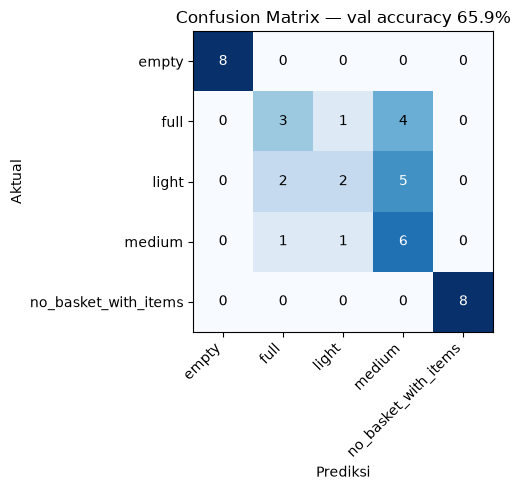

  empty                   100.0%
  full                     37.5%
  light                    22.2%
  medium                   75.0%
  no_basket_with_items    100.0%


In [5]:
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms

eval_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
val_ds = datasets.ImageFolder("dataset/val", transform=eval_tf)
CLASSES = val_ds.classes

model = models.mobilenet_v2(weights=None)
model.classifier[1] = nn.Linear(model.last_channel, len(CLASSES))
model.load_state_dict(torch.load("fullness_classifier.pt", map_location=device))
model.to(device).eval()

cm = np.zeros((len(CLASSES), len(CLASSES)), dtype=int)
with torch.no_grad():
    for x, y in DataLoader(val_ds, batch_size=16):
        pred = model(x.to(device)).argmax(1).cpu().numpy()
        for t, p in zip(y.numpy(), pred):
            cm[t, p] += 1

acc = cm.trace() / cm.sum()
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(CLASSES)), CLASSES, rotation=45, ha="right")
ax.set_yticks(range(len(CLASSES)), CLASSES)
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black")
ax.set_xlabel("Prediksi"); ax.set_ylabel("Aktual")
ax.set_title(f"Confusion Matrix — val accuracy {acc:.1%}")
plt.tight_layout(); plt.show()

per_class = cm.diagonal() / cm.sum(1)
for c, a in zip(CLASSES, per_class):
    print(f"  {c:<24}{a:6.1%}")


## 5. Prediksi Gambar

### 5.1 Satu gambar utuh

⚠️ **Classifier ini dilatih pada crop/foto keranjang**, bukan adegan toko utuh. Di pipeline final, YOLO mendeteksi keranjang dulu → crop-nya baru diklasifikasi. Foto adegan penuh orang biasanya jatuh ke `no_basket_with_items` dengan confidence rendah — itu perilaku yang wajar.

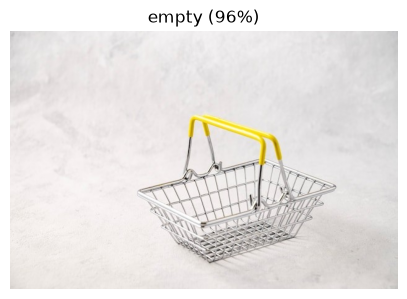

empty=0.96  full=0.00  light=0.03  medium=0.00  no_basket_with_items=0.00


In [6]:
import torch.nn.functional as F
from PIL import Image

def predict_image(img: Image.Image):
    x = eval_tf(img.convert("RGB")).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = F.softmax(model(x), dim=1)[0].cpu()
    idx = int(probs.argmax())
    return CLASSES[idx], float(probs[idx]), probs.tolist()

# ganti path ini dengan foto apa pun yang mau dites
SAMPLE = sorted(Path("dataset/val").rglob("*.jpg"))[0]
img = Image.open(SAMPLE)
label, conf, probs = predict_image(img)

plt.figure(figsize=(5, 4)); plt.imshow(img); plt.axis("off")
plt.title(f"{label} ({conf:.0%})"); plt.show()
print("  ".join(f"{c}={p:.2f}" for c, p in zip(CLASSES, probs)))


### 5.2 Foto antrian → crop tiap keranjang (menirukan pipeline YOLO)

Untuk foto antrian kasir (banyak orang, beberapa keranjang), cara tes yang benar: **crop tiap keranjang lalu prediksi masing-masing**. Isi `BOXES` dengan koordinat piksel `(kiri, atas, kanan, bawah)` tiap keranjang — di sistem final koordinat ini datang otomatis dari YOLO basket detection.

Ganti `QUEUE_IMG` dengan foto antrianmu (mis. hasil *Save image as...* dari foto stok).

In [7]:
QUEUE_IMG = None            # contoh: "~/Downloads/antrian.jpg"
BOXES = [                   # (kiri, atas, kanan, bawah) per keranjang — dari YOLO nantinya
    # (140, 230, 300, 340),
    # (330, 250, 470, 360),
]

if QUEUE_IMG:
    scene = Image.open(Path(QUEUE_IMG).expanduser()).convert("RGB")
    n = len(BOXES) + 1
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    axes[0].imshow(scene); axes[0].set_title("adegan utuh"); axes[0].axis("off")
    for ax, box in zip(axes[1:], BOXES):
        crop = scene.crop(box)
        label, conf, _ = predict_image(crop)
        ax.imshow(crop); ax.axis("off")
        ax.set_title(f"{label} ({conf:.0%})")
    plt.tight_layout(); plt.show()
else:
    print("Set QUEUE_IMG ke path foto antrian untuk mencoba bagian ini.")


Set QUEUE_IMG ke path foto antrian untuk mencoba bagian ini.


## 6. Prediksi Waktu Checkout — Online Learning

Sesuai MASTER_PROMPT §5-6: waktu checkout diprediksi **regresi linear online** yang belajar dari feedback tiap transaksi (SGD), *bukan* model statis:

```
predicted_time = intercept + slope × jumlah_item
error          = actual − predicted
intercept     += lr_i × error
slope         += lr_s × error × jumlah_item
```

Simulasi di bawah memutar 120 transaksi sintetis (dibangun dari formula `20 + 7×item` + noise kasir + 12% outlier delay) **satu per satu**, seolah datang real-time. Parameter mulai dari tebakan sengaja meleset (10, 4) dan harus konvergen mendekati (20, 7) — bukti mekanisme belajarnya bekerja. Saat deployed, mekanisme yang sama belajar dari data checkout asli tanpa ubah kode.

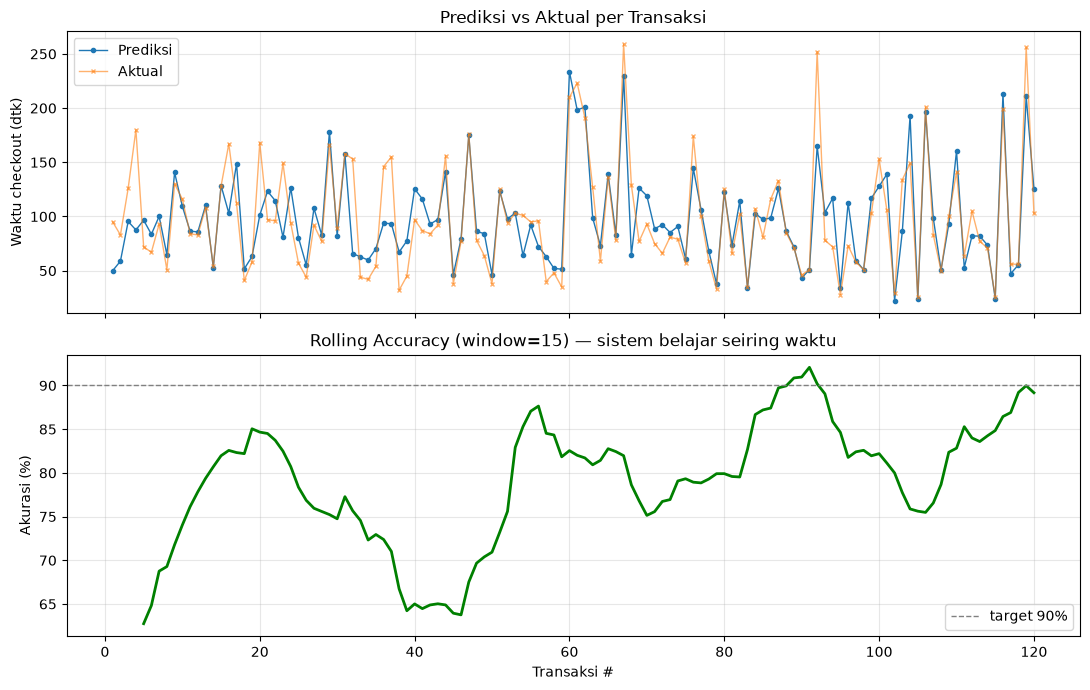

Akurasi 10 transaksi pertama : 74.0%
Akurasi 10 transaksi terakhir: 88.0%
Parameter akhir: intercept=23.5 (asli 20), slope=8.51 (asli 7)


In [8]:
import pandas as pd
from online_learning_simulation import run_simulation, compute_rolling_accuracy

df = pd.read_csv("synthetic_checkout_data.csv")
results = run_simulation(df)
rolling = compute_rolling_accuracy(results)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(results["transaction_id"], results["predicted_checkout_time_sec"],
             label="Prediksi", marker="o", ms=3, lw=1)
axes[0].plot(results["transaction_id"], results["actual_checkout_time_sec"],
             label="Aktual", marker="x", ms=3, lw=1, alpha=0.6)
axes[0].set_ylabel("Waktu checkout (dtk)"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title("Prediksi vs Aktual per Transaksi")

axes[1].plot(results["transaction_id"], rolling, color="green", lw=2)
axes[1].axhline(90, color="gray", ls="--", lw=1, label="target 90%")
axes[1].set_ylabel("Akurasi (%)"); axes[1].set_xlabel("Transaksi #")
axes[1].set_title("Rolling Accuracy (window=15) — sistem belajar seiring waktu")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

first = 100 - results["abs_pct_error"].iloc[:10].mean()
last = 100 - results["abs_pct_error"].iloc[-10:].mean()
print(f"Akurasi 10 transaksi pertama : {first:.1f}%")
print(f"Akurasi 10 transaksi terakhir: {last:.1f}%")
print(f"Parameter akhir: intercept={results['current_intercept'].iloc[-1]:.1f} "
      f"(asli 20), slope={results['current_slope'].iloc[-1]:.2f} (asli 7)")
INTERCEPT = float(results["current_intercept"].iloc[-1])
SLOPE = float(results["current_slope"].iloc[-1])


### 6.1 Gabungan: kelas fullness → estimasi waktu checkout

Jembatan antara classifier (Bagian 3-5) dan prediksi waktu (Bagian 6): tiap kelas fullness dipetakan ke **perkiraan jumlah item** (titik tengah rentang labelnya), lalu masuk formula regresi. Inilah angka yang tampil di dashboard & menentukan warna lampu lane.

In [9]:
FULLNESS_TO_ITEMS = {
    "empty": 0,                  # tetap ada overhead (bayar, sapa kasir)
    "light": 3,                  # titik tengah 1-5
    "medium": 10,                # titik tengah 6-15
    "full": 23,                  # titik tengah 16-30
    "no_basket_with_items": 2,   # bawa tangan biasanya sedikit
}

print(f"predicted_time = {INTERCEPT:.1f} + {SLOPE:.2f} × jumlah_item\n")
print(f"{'kelas':<24}{'± item':>7}{'estimasi waktu':>18}")
for cls, items in FULLNESS_TO_ITEMS.items():
    t = INTERCEPT + SLOPE * items
    print(f"{cls:<24}{items:>7}{t:>14.0f} dtk")

# contoh: satu lane berisi 3 customer -> total perkiraan waktu tunggu
lane = ["full", "light", "medium"]
total = sum(INTERCEPT + SLOPE * FULLNESS_TO_ITEMS[c] for c in lane)
print(f"\nContoh lane {lane}: perkiraan tunggu ±{total:.0f} dtk ({total/60:.1f} menit)")


predicted_time = 23.5 + 8.51 × jumlah_item

kelas                    ± item    estimasi waktu
empty                         0            23 dtk
light                         3            49 dtk
medium                       10           109 dtk
full                         23           219 dtk
no_basket_with_items          2            40 dtk

Contoh lane ['full', 'light', 'medium']: perkiraan tunggu ±377 dtk (6.3 menit)


## 7. Status & Langkah Berikutnya

| Komponen | Status |
|---|---|
| Environment CUDA (torch cu126, Pascal) | ✅ jalan |
| Dataset scaffolding + scraper (foto & video) | ✅ jalan — data scrape perlu kurasi |
| Fullness classifier (MobileNetV2) | ✅ terlatih — baseline dari data scrape |
| Prediksi waktu checkout (online SGD) | ✅ teruji di data sintetis |
| Person/basket detection (YOLO pretrained) | ⬜ berikutnya |
| Dashboard Next.js + Supabase, LED ESP32 | ⬜ berikutnya |

**Menaikkan akurasi classifier** (urutan dampak):
1. Kurasi `dataset/raw/light/` & `medium/` — buang foto salah kelas hasil scrape.
2. Rekam keranjang asli per tahap isi (`extract_frames.py`) — target ±30-35 foto/kelas dari sudut kamera deployment.
3. Jalankan ulang Bagian 2.1 → 3 → 4 dan bandingkan confusion matrix-nya.